In [1]:
import pandas as pd
import numpy as np
import pickle
import obspy
from seismicif.datamod.loading_utils import (
    find_paths,
    preproc_flow_annotations,
    find_date_in_strings,
    extract_split_flows,
    extract_template,
    read_segment,
    remove_duplicate_traces,
    remove_overlaps,
    sliding_windows_from_trace,
    limit_segment_length,
)
from seismicif.datamod.preproc_utils import preproc_stream
from seismicif.metrics import iou
from seismicif.dtw import segment_dtw
from joblib import dump, load
from datetime import timedelta
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform


def find_fp_fn(df, gt):
    if len(df) == 0:
        FP = np.nan
        FN = gt

    else:
        I, U, _ = iou(df, gt)
        FP = df.iloc[np.where(np.append(I[0], np.diff(I)) == 0)[0], :]

        I, U, _ = iou(gt, df)
        FN = gt.iloc[np.where(np.append(I[0], np.diff(I)) == 0)[0], :]

    return FP, FN


def normalize_stream_to_unit_range(stream: obspy.Stream) -> obspy.Stream:
    """
    Normalize all traces in an ObsPy Stream so that each trace's data
    lies in the range [0, 1].
    """
    normed_stream = stream.copy()
    for tr in normed_stream:
        data = tr.data.astype(np.float64)
        min_val = np.min(data)
        max_val = np.max(data)
        if max_val != min_val:  # avoid division by zero
            tr.data = (data - min_val) / (max_val - min_val)
        else:
            tr.data = np.zeros_like(data)  # or leave as-is
    return normed_stream

In [2]:
with open(f"../output/DK/dtw/info/NUUG.pkl", "rb") as f:
    info = pickle.load(f)

In [3]:
indices = info[0]
d = np.array([np.median(i[0]) for i in info[1]])

D = np.zeros([50, 50])

for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = d[n]

D = D + D.T

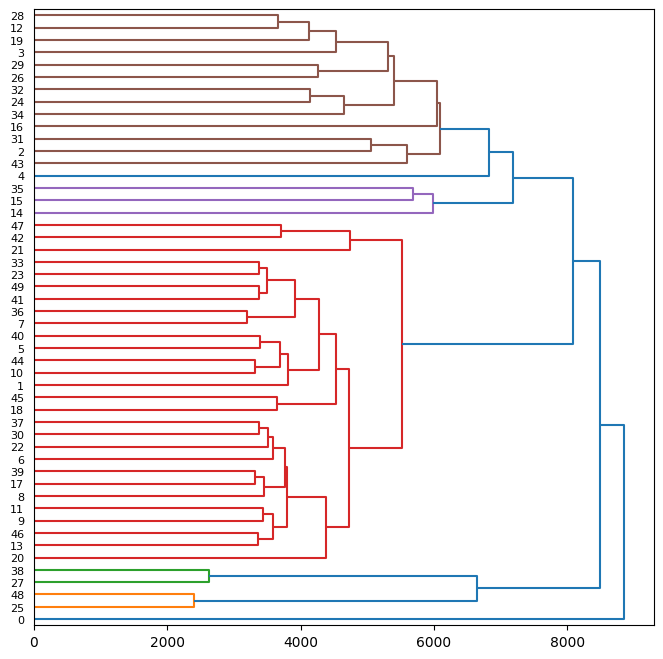

In [4]:
Z = linkage(squareform(D), method="complete")
plt.figure(figsize=(8, 8))
dendrogram(Z, orientation="right")
plt.show()

In [5]:
info[1][0]

([5343.110222508704,
  5749.0212035954955,
  6650.946844887679,
  5273.812312252939,
  4445.51234987167,
  5082.700537455151,
  5036.95476004742,
  3926.245522969458,
  4520.582696052792,
  3094.3586790679306,
  3462.0945777803327,
  3588.940479829895,
  3633.1576254156175,
  4072.8423373146943,
  3980.091981004464,
  4152.032775195013,
  3968.718517189916,
  4226.400909391421,
  4497.578659493655,
  6507.069005250454,
  4977.414563623832,
  5411.931607040308,
  6257.115374840402,
  6524.148782691048,
  7108.954721593549,
  7525.376623932331,
  8467.134677998993,
  9111.0003435457,
  8833.447513632582,
  8490.053491505447,
  8231.323787086434,
  8950.298351571992,
  9017.362059274063,
  9110.92300877245,
  9214.900727453343,
  9141.399408520347,
  9419.61180150755,
  9122.254619148485,
  8939.247780575404,
  8546.499907884709,
  8476.921014781283,
  8851.96300033536,
  9431.909059717036,
  9000.16745240922],
 [(0, 0),
  (1, 1),
  (2, 2),
  (2, 3),
  (3, 4),
  (3, 5),
  (3, 6),
  (3, 7)

In [7]:
with open(f"../output/DK/dtw/info/KARAT.pkl", "rb") as f:
    info = pickle.load(f)

In [8]:
labs = np.array(pd.read_csv("../catalogs/DK/KARAT.csv", index_col=0)["labels"])

for i in range(labs.shape[0]):
    labs[i] = labs[i] + "  " + str(i + 1)

In [9]:
indices = info[0]
d = np.array([np.median(i[0]) for i in info[1]])

In [10]:
D = np.zeros([50, 50])

for n in range(len(indices)):
    i, j = indices[n]

    D[i, j] = d[n]

D = D + D.T

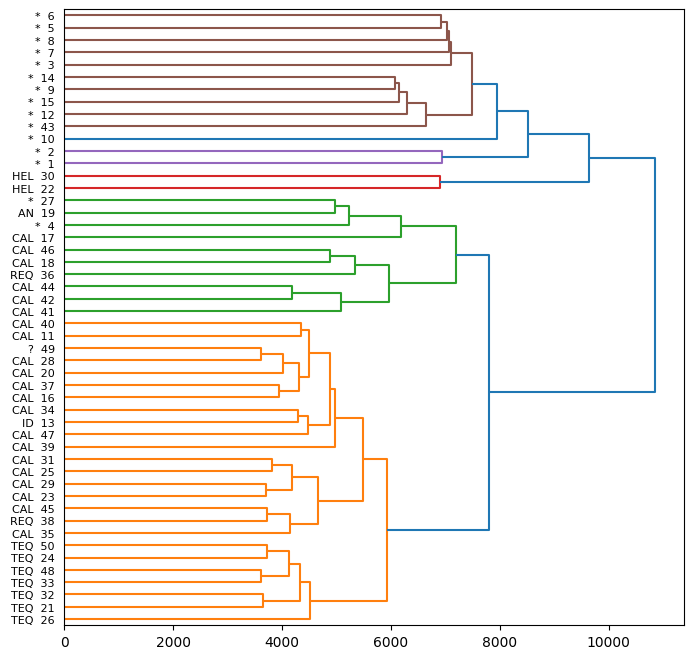

In [11]:
Z = linkage(squareform(D), method="complete")
plt.figure(figsize=(8, 8))
dendrogram(Z, orientation="right", labels=labs)
plt.show()

In [3]:
paths = find_paths("DK", "NUUG", "HHZ.D", 2017, 2017)
if_mod = load(f"../output/DK/if/models/NUUG.joblib")
segments = preproc_flow_annotations(
    pd.read_csv("../output/DK/if/segments/NUUG.csv", index_col=0)
)

In [4]:
print(segments.iloc[9, 0], segments.iloc[9, 1])

2017-06-26T02:57:31.680001Z 2017-06-28T09:58:21.680001Z


In [5]:
seg2 = limit_segment_length(
    segments.iloc[9, 0], segments.iloc[9, 1], paths, if_mod, max_len=3600, stride=10000
)

In [11]:
seg2 = limit_segment_length(
    segments.iloc[9, 0], segments.iloc[9, 1], paths, if_mod, max_len=3600, stride=5000
)

In [4]:
seg1 = limit_segment_length(segments.iloc[2, 0], segments.iloc[2, 1], paths, if_mod)
seg2 = limit_segment_length(segments.iloc[9, 0], segments.iloc[9, 1], paths, if_mod)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from obspy import Stream, Trace
from scipy.signal import spectrogram as scipy_spectrogram


def plot_waveforms_and_spectrograms(
    data, wlen=10, log=False, figsize=(12, 4), cmap="viridis", save_path=None
):
    # Normalize input
    if isinstance(data, Trace):
        data = Stream(traces=[data])
    elif not isinstance(data, Stream):
        raise TypeError("Input must be an ObsPy Stream or Trace.")

    n = len(data)

    # Compute all spectrograms and find global min/max
    spectrograms = []
    global_min, global_max = np.inf, -np.inf

    for tr in data:
        fs = tr.stats.sampling_rate
        nperseg = int(wlen * fs)
        f, t, Sxx = scipy_spectrogram(tr.data, fs=fs, nperseg=nperseg)
        if log:
            Sxx = 10 * np.log10(Sxx + 1e-10)
        spectrograms.append((f, t, Sxx))
        global_min = min(global_min, Sxx.min())
        global_max = max(global_max, Sxx.max())

    # Create subplots (always 2 columns: waveform + spectrogram)
    fig, axes = plt.subplots(n, 2, figsize=(figsize[0], figsize[1] * n))

    # Normalize axes to always be 2D array-like
    if n == 1:
        axes = [axes]  # single row of 2 axes -> wrap in list

    for i, tr in enumerate(data):
        ax_wave, ax_spec = axes[i]

        # Plot waveform
        times = tr.times()
        ax_wave.plot(times, tr.data, "k")
        ax_wave.set_title(f"{tr.id} — {tr.stats.starttime.date}")
        for label in ax_wave.get_xticklabels():
            label.set_rotation(30)
            label.set_horizontalalignment("right")

        # Plot spectrogram with fixed color scale
        f, t, Sxx = spectrograms[i]
        im = ax_spec.pcolormesh(
            t, f, Sxx, shading="gouraud", cmap=cmap, vmin=global_min, vmax=global_max
        )
        ax_spec.set_ylabel("Frequency [Hz]")
        ax_spec.set_xlabel("Time [s]")
        ax_spec.set_title(f"{tr.id}")

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="Power")

    # Adjust layout
    fig.subplots_adjust(right=0.9, hspace=0.5)

    if save_path:
        fig.savefig(save_path)
        print(f"Saved to {save_path}")

    plt.show()
    return fig

In [ ]:
# flows = flows.iloc[np.argsort(flows["start"]),:].reset_index(drop=True)
# flows.to_csv("../catalogs/XP/flow_catalog.csv")

In [42]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)

In [43]:
confirmed_FP = preproc_flow_annotations(pd.read_csv("../catalogs/XP/confirmed_FP.csv"))
# to_confirm = preproc_flow_annotations(pd.read_csv("../catalogs/XP/to_confirm.csv"))

remove_dict = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    remove_dict[station] = pd.concat(
        [
            confirmed_FP[confirmed_FP["station"] == station].iloc[:, [0, 1, 2, 5]],
            # to_confirm[to_confirm["station"] == station],
        ]
    ).reset_index(drop=True)

In [44]:
stations = ["ILL11", "ILL12", "ILL13", "ILL18"]
if_detections = {}
sta_lta_detections = {}
dtw_detections = {}

for station in stations:
    if_detections[station] = pd.read_csv(
        f"../output/XP/if/detections/{station}.csv", index_col=0
    )
    sta_lta_detections[station] = pd.read_csv(
        f"../output/XP/sta_lta/detections/{station}.csv", index_col=0
    )

stations = ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]

for station in stations:
    dtw_detections[station] = pd.read_csv(
        f"../output/XP/if_dtw/detections/{station}.csv", index_col=0
    )

In [45]:
IF_FP = {}
STA_LTA_FP = {}
DTW_FP = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    _, _, station_flows = extract_split_flows(flows, station, 2018, 2022)
    IF_FP[station] = find_fp_fn(if_detections[station], station_flows)[0].reset_index(
        drop=True
    )
    STA_LTA_FP[station] = find_fp_fn(sta_lta_detections[station], station_flows)[
        0
    ].reset_index(drop=True)

for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    _, _, station_flows = extract_split_flows(flows, station, 2018, 2022)
    DTW_FP[station] = find_fp_fn(dtw_detections[station], station_flows)[0].reset_index(
        drop=True
    )

In [46]:
if_unconfirmed = {}

for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    FP = find_fp_fn(IF_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    if_unconfirmed[station] = FP.reset_index(drop=True)

In [47]:
sta_lta_unconfirmed = {}

for station in ["ILL11", "ILL12", "ILL13", "ILL18"]:
    FP = find_fp_fn(STA_LTA_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    sta_lta_unconfirmed[station] = FP.reset_index(drop=True)

In [48]:
dtw_unconfirmed = {}
for station in ["ILL11", "ILL12", "ILL13", "ILL14", "ILL16", "ILL17", "ILL18"]:
    FP = find_fp_fn(DTW_FP[station], remove_dict[station])[0]

    if FP is np.nan:
        continue

    if len(FP) == 0:
        continue

    dtw_unconfirmed[station] = FP.reset_index(drop=True)

In [49]:
for station in sta_lta_unconfirmed:
    print(station, sta_lta_unconfirmed[station])

In [50]:
for station in dtw_unconfirmed:
    print(station, dtw_unconfirmed[station])

In [51]:
for station in if_unconfirmed:
    print(station, if_unconfirmed[station])

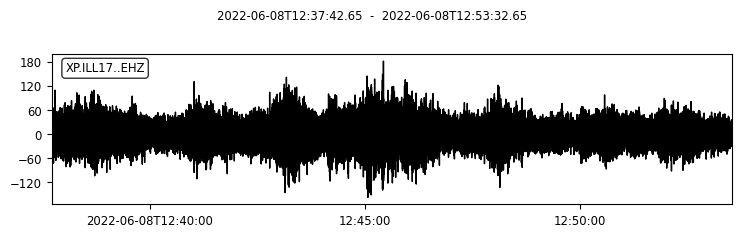

In [88]:
# Nothing really
paths = find_paths("XP", "ILL17", "EHZ.D", 2022, 2022)
t0 = obspy.UTCDateTime("2022-06-08T12:37:42.650000Z")
t1 = obspy.UTCDateTime("2022-06-08T12:53:32.650000Z")
st = obspy.read(find_date_in_strings(paths, "2022-06-08")[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

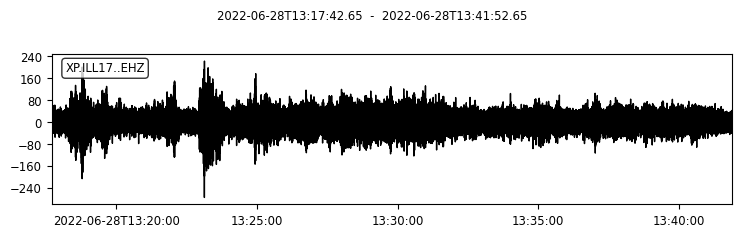

In [89]:
# Very weak signal, perhaps something in the upper catchment
paths = find_paths("XP", "ILL17", "EHZ.D", 2022, 2022)
t0 = obspy.UTCDateTime("2022-06-28T13:17:42.650000Z")
t1 = obspy.UTCDateTime("2022-06-28T13:41:52.650000Z")
st = obspy.read(find_date_in_strings(paths, "2022-06-28")[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

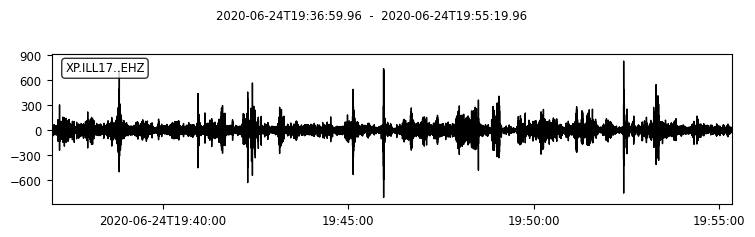

In [90]:
# Weak and only visible on ILL17, so probably nothing
paths = find_paths("XP", "ILL17", "EHZ.D", 2020, 2020)
t0 = obspy.UTCDateTime("2020-06-24T19:36:59.960000Z")
t1 = obspy.UTCDateTime("2020-06-24T19:55:19.960000Z")
st = obspy.read(find_date_in_strings(paths, "2020-06-24")[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

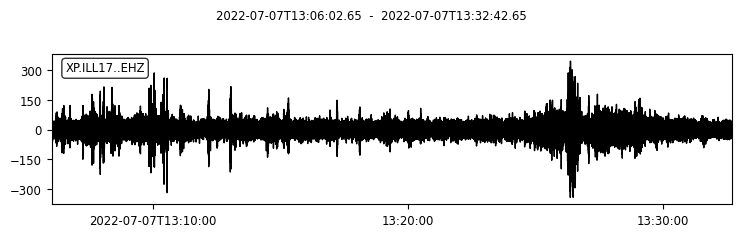

In [91]:
## ILL17,2022-07-07T13:06:02.650000Z,2022-07-07T13:32:42.650000Z,DTW,Nothing or only VERY weak.,"
paths = find_paths("XP", "ILL17", "EHZ.D", 2022, 2022)
t0 = obspy.UTCDateTime("2022-07-07T13:06:02.650000Z")
t1 = obspy.UTCDateTime("2022-07-07T13:32:42.650000Z")
st = obspy.read(find_date_in_strings(paths, "2022-07-07")[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

In [ ]:
# .,Helicopter/Airplane towards the beginning pf the detection?
#

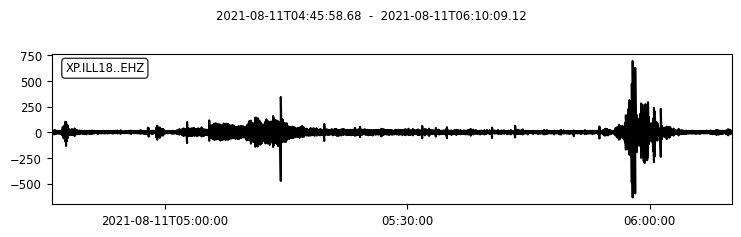

In [ ]:
# I do not see anything.
paths = find_paths("XP", "ILL18", "EHZ.D", 2021, 2021)
t0 = obspy.UTCDateTime("2021-08-11T04:45:58.680000Z")
t1 = obspy.UTCDateTime("2021-08-11T06:10:09.120000Z")
st = obspy.read(find_date_in_strings(paths, "2021-08-11")[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

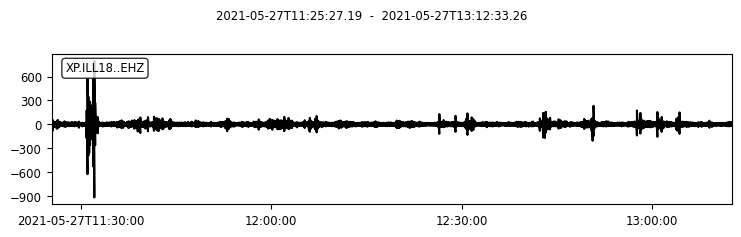

In [ ]:
# I don’t see anything
paths = find_paths("XP", "ILL18", "EHZ.D", 2021, 2021)
t0 = obspy.UTCDateTime("2021-05-27T11:25:27.190000Z")
t1 = obspy.UTCDateTime("2021-05-27T13:12:33.260000Z")
st = obspy.read(find_date_in_strings(paths, "2021-05-27")[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

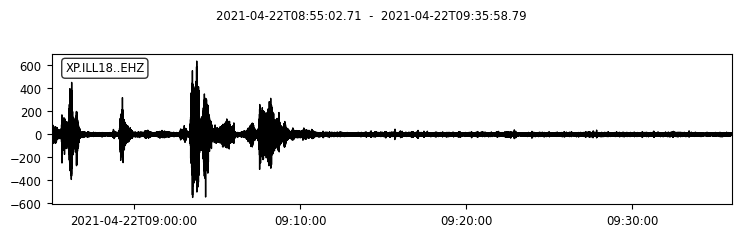

In [97]:
# ILL18,2021-04-22T08:55:02.710000Z,2021-04-22T09:35:58.790000Z,STA-LTA,I don't see anything towards the beginning of the detection. Some strong noise signals after 10:30.,only ILL18 active
paths = find_paths("XP", "ILL18", "EHZ.D", 2021, 2021)
t0 = obspy.UTCDateTime("2021-04-22T08:55:02.710000Z")
t1 = obspy.UTCDateTime("2021-04-22T09:35:58.790000Z")
st = obspy.read(find_date_in_strings(paths, "2021-04-22")[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

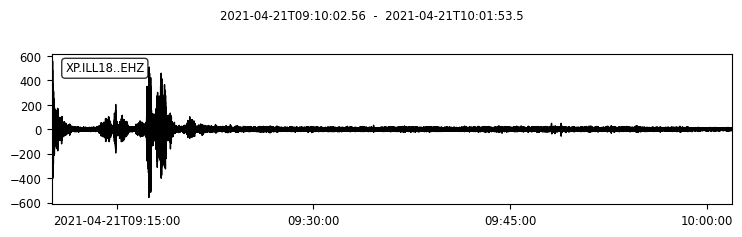

In [101]:
# ILL18,2021-04-21T09:10:02.560000Z,2021-04-21T10:01:53.500000Z,STA-LTA,"Weak signal, probably noise, but only ILL18 running."
paths = find_paths("XP", "ILL18", "EHZ.D", 2021, 2021)
t0 = obspy.UTCDateTime("2021-04-21T09:10:02.560000Z")
t1 = obspy.UTCDateTime("2021-04-21T10:01:53.500000Z")
st = obspy.read(find_date_in_strings(paths, "2021-04-21")[0])
preproc_stream(st)
st.trim(t0, t1)
st.plot()
plt.show()

In [143]:
from obspy import read
from obspy.signal.trigger import classic_sta_lta, trigger_onset, plot_trigger

In [165]:
# I do not see anything.
paths = find_paths("XP", "ILL18", "EHZ.D", 2021, 2021)
st = obspy.read(find_date_in_strings(paths, "2021-08-11")[0])
preproc_stream(st)
st_new = obspy.read(find_date_in_strings(paths, "2021-08-10")[0])
preproc_stream(st_new)
st += st_new

In [166]:
tr = obspy.Trace()
tr.data = np.append(st[2], st[0])
tr.stats.sampling_rate = 100
tr.stats.starttime = obspy.UTCDateTime("2021-08-10T17:25:42.660000Z")

In [167]:
sta = int(50000.0)
lta = int(4000000)

cft = classic_sta_lta(tr.data, sta, lta)
tr.stats.starttime + timedelta(seconds=on_off[0][0] / 100)

2021-08-11T05:10:58.680000Z

In [168]:
sta_lta_tr = obspy.Trace()
sta_lta_tr.data = cft
sta_lta_tr.stats.sampling_rate = 100
sta_lta_tr.stats.starttime = tr.stats.starttime

In [169]:
t0 = obspy.UTCDateTime("2021-08-11T03:10:58.680000Z")
t1 = obspy.UTCDateTime("2021-08-11T09:10:09.120000Z")

In [170]:
tr.trim(t0, t1)
sta_lta_tr.trim(t0, t1)

... | 2021-08-11T03:10:58.680000Z - 2021-08-11T09:10:09.120000Z | 100.0 Hz, 2155045 samples

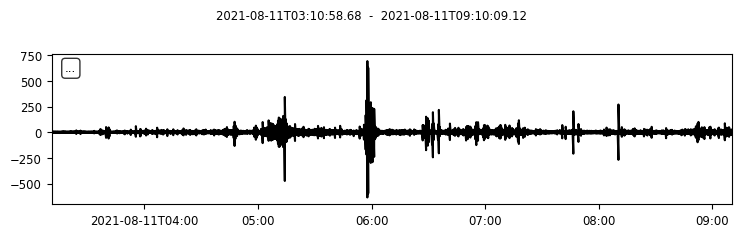

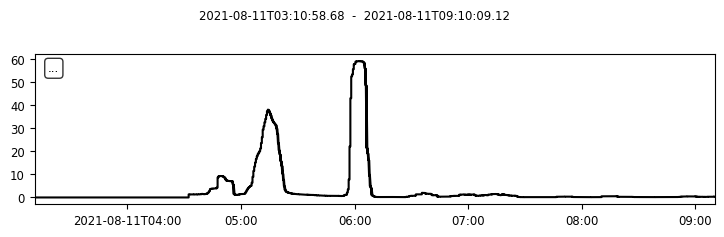

<function matplotlib.pyplot.show(close=None, block=None)>

In [172]:
tr.plot()
sta_lta_tr.plot()
plt.show

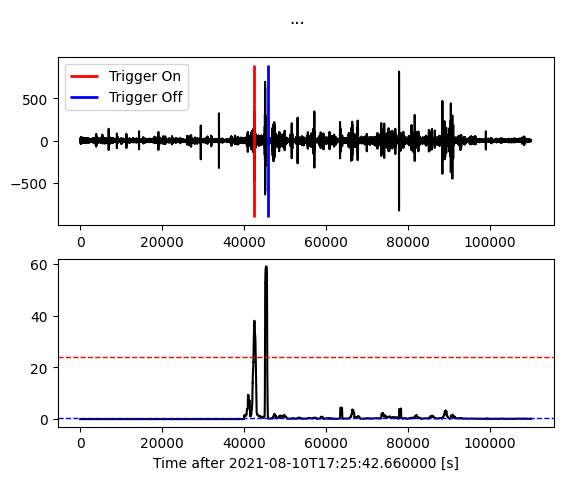

In [152]:
on_off = trigger_onset(cft, 24, 0.5)
plot_trigger(tr, cft, 24, 0.5)

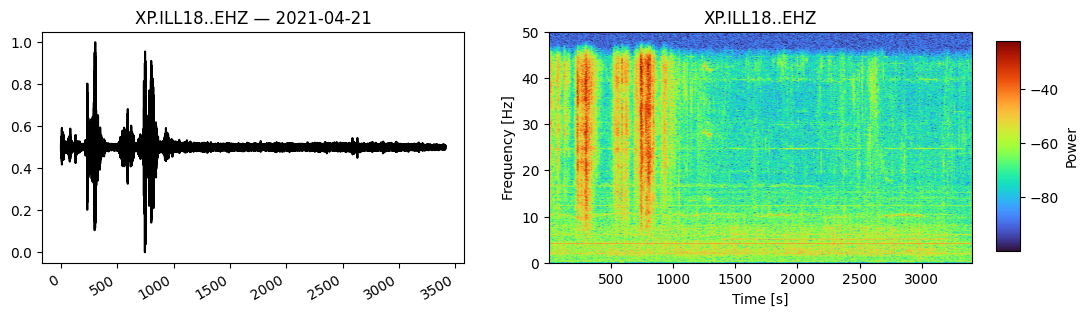

In [ ]:
# fig =plot_waveforms_and_spectrograms(streams,figsize=(12, 3),log=True,cmap="turbo")